<a href="https://colab.research.google.com/github/samithdhananjaya/phishing_site_urls/blob/main/IT25102012_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy scikit-learn

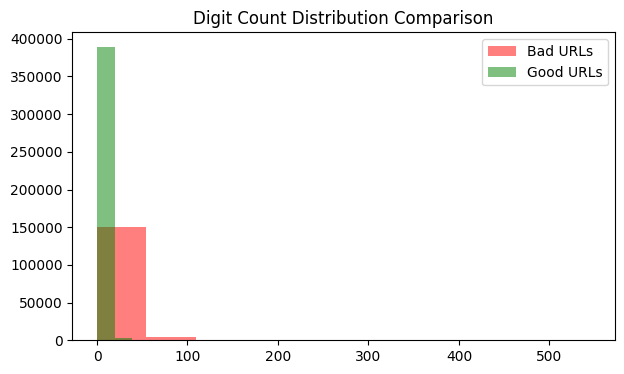

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('phishing_site_urls.csv')


# Custom Features Creation
def has_ip_address(url):
  ip_pattern = (
      r'(([01]?\d\d?|2[0-4]\d|25[0-5])\.){3}([01]?\d\d?|2[0-4]\d|25[0-5])'
  )
  return 1 if re.search(ip_pattern, str(url)) else 0


df['has_ip'] = df['URL'].apply(has_ip_address)
df['count_digits'] = df['URL'].apply(lambda x: sum(c.isdigit() for c in str(x)))

# Visualization: Histogram of Digit Count by Class
plt.figure(figsize=(7, 4))
plt.hist(
    df[df['Label'] == 'bad']['count_digits'],
    alpha=0.5,
    label='Bad URLs',
    color='red',
)
plt.hist(
    df[df['Label'] == 'good']['count_digits'],
    alpha=0.5,
    label='Good URLs',
    color='green',
)
plt.legend()
plt.title('Digit Count Distribution Comparison')

plt.show()